In [12]:
# Install Required Libraries
!pip install pandas numpy matplotlib seaborn

In [13]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional Settings
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')

<Figure size 800x500 with 0 Axes>

In [15]:
# Upload Dataset
from google.colab import files

uploaded = files.upload()

Saving Bank Customer Churn Prediction.csv to Bank Customer Churn Prediction.csv


In [16]:
# Load Dataset
df = pd.read_csv('Bank Customer Churn Prediction.csv')

In [17]:
# View Dataset
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
# Dataset Information
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(10000, 12)

Columns:
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn            

In [20]:
# Check Missing Values
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [21]:
# Check Duplicate Values
df.duplicated().sum()

np.int64(0)

In [22]:
# Remove Duplicate Records (If Any)
df = df.drop_duplicates()

In [23]:
# Check Data Types
df.dtypes

,0
customer_id,int64
credit_score,int64
country,object
gender,object
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64


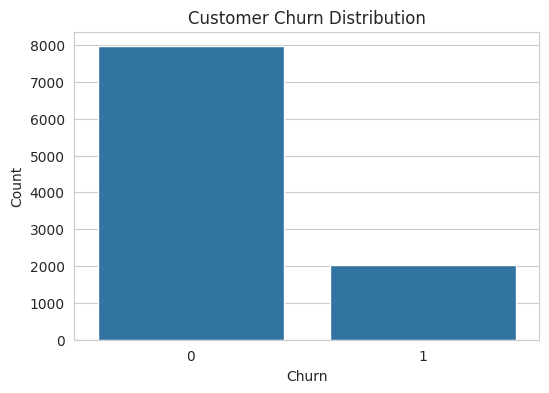

In [24]:
# Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

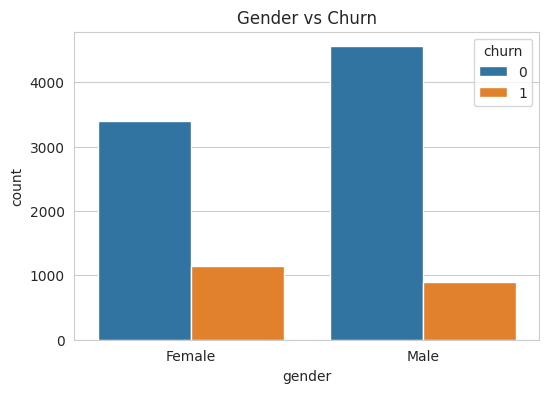

In [25]:
# Gender vs Churn

plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='churn', data=df)

plt.title('Gender vs Churn')

plt.show()

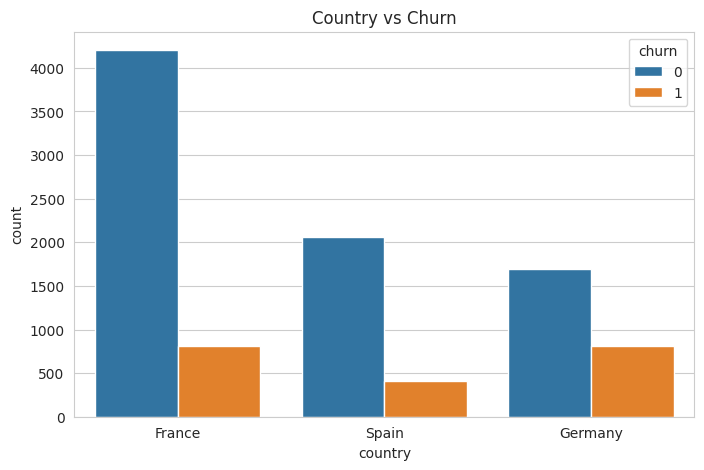

In [26]:
# Country vs Churn

plt.figure(figsize=(8,5))

sns.countplot(x='country', hue='churn', data=df)

plt.title('Country vs Churn')

plt.show()

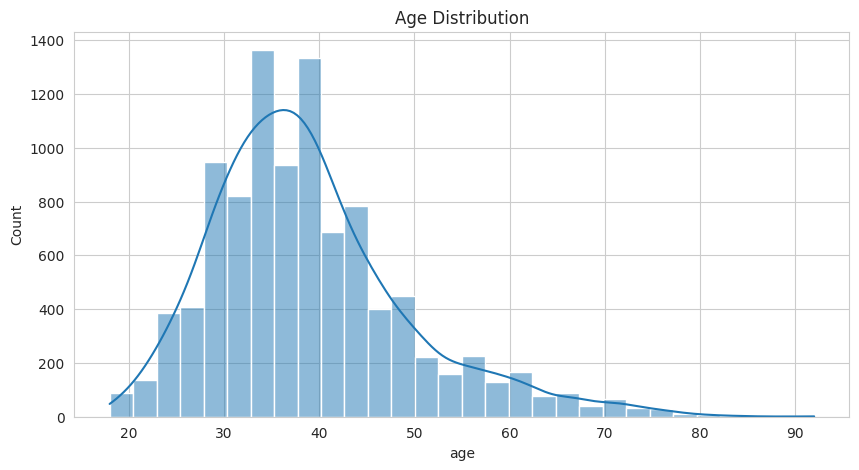

In [27]:
# Age Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title('Age Distribution')

plt.show()

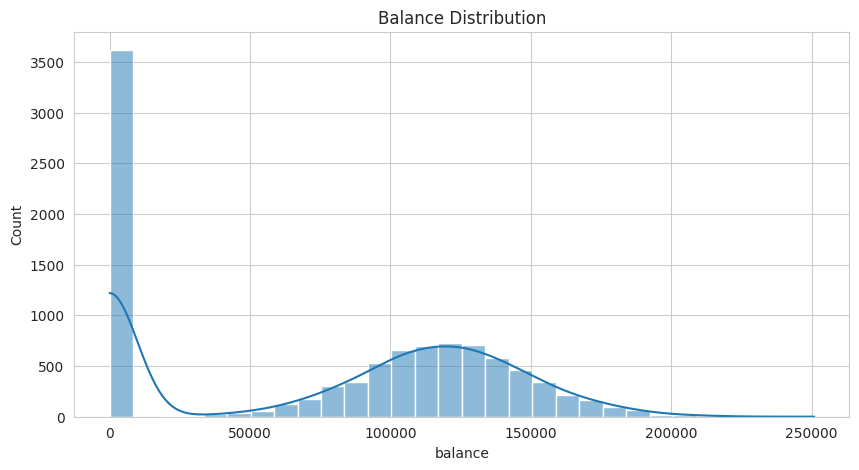

In [28]:
# Balance Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['balance'], bins=30, kde=True)

plt.title('Balance Distribution')

plt.show()

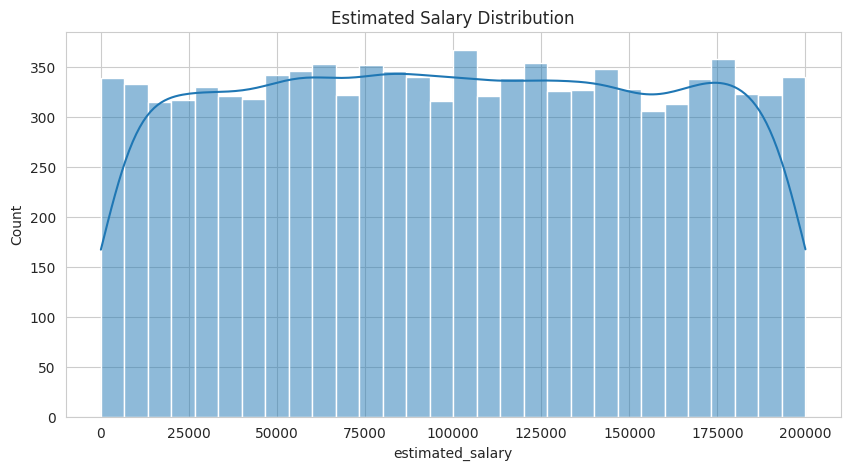

In [29]:
# Salary Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['estimated_salary'], bins=30, kde=True)

plt.title('Estimated Salary Distribution')

plt.show()

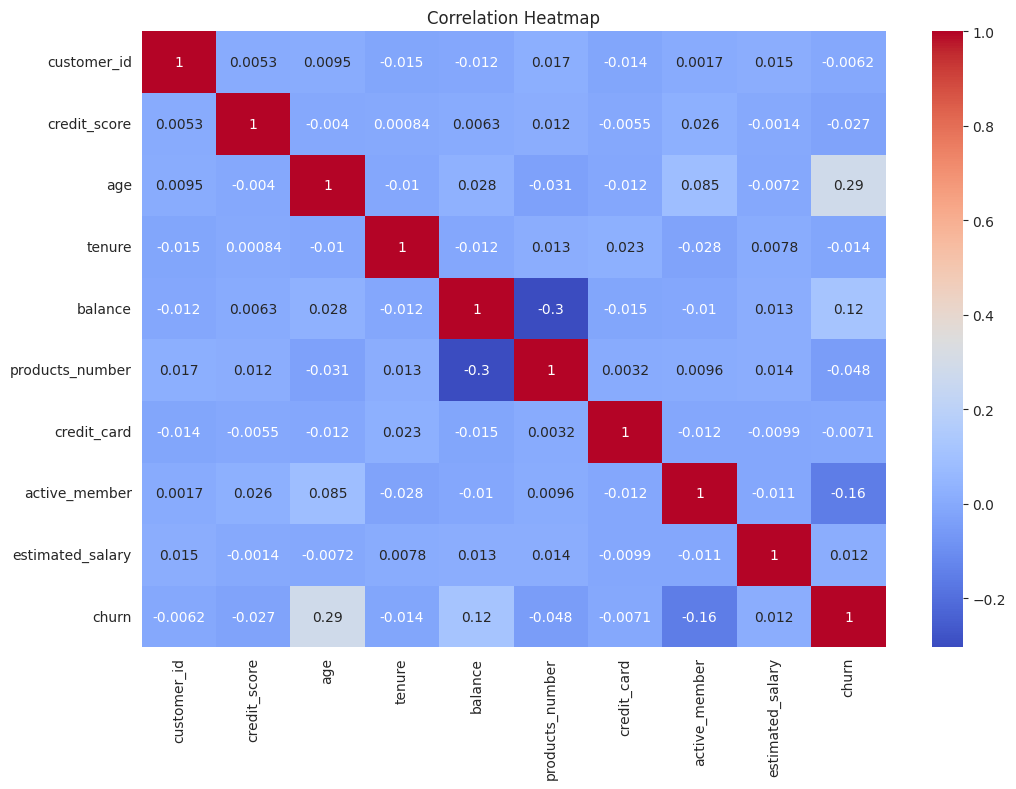

In [30]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [31]:
# Average Age by Churn
df.groupby('churn')['age'].mean()

,age
churn,
0,37.408389
1,44.837997


In [32]:
# Average Balance by Churn
df.groupby('churn')['balance'].mean()

,balance
churn,
0,72745.296779
1,91108.539337


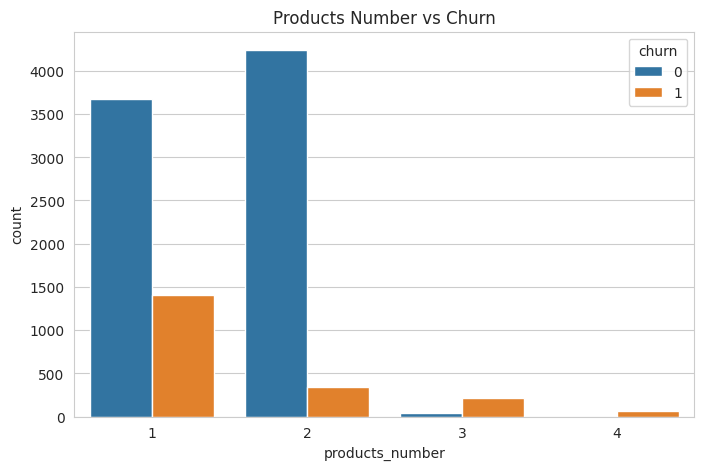

In [33]:
# Products Number vs Churn

plt.figure(figsize=(8,5))

sns.countplot(x='products_number', hue='churn', data=df)

plt.title('Products Number vs Churn')

plt.show()

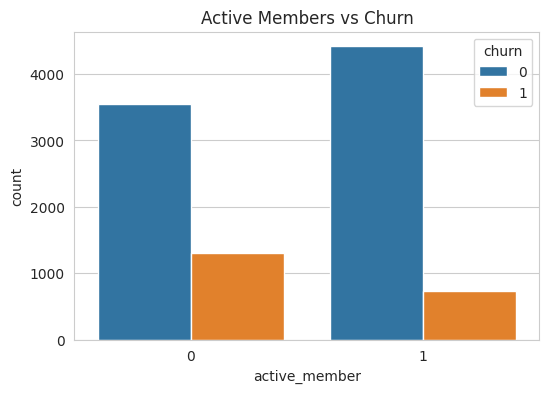

In [34]:
# Active Members vs Churn

plt.figure(figsize=(6,4))

sns.countplot(x='active_member', hue='churn', data=df)

plt.title('Active Members vs Churn')

plt.show()

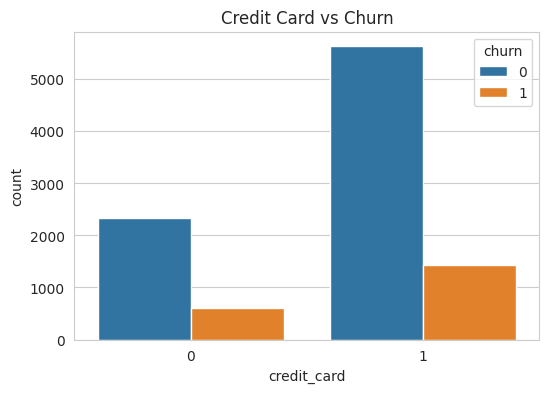

In [35]:
# Credit Card vs Churn

plt.figure(figsize=(6,4))

sns.countplot(x='credit_card', hue='churn', data=df)

plt.title('Credit Card vs Churn')

plt.show()

In [36]:
# Churn Rate

churn_rate = (df['churn'].sum() / len(df)) * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


In [37]:
# Country-wise Churn Rate

country_churn = df.groupby('country')['churn'].mean() * 100

country_churn.sort_values(ascending=False)

,churn
country,
Germany,32.443204
Spain,16.673395
France,16.154767


In [38]:
# Gender-wise Churn Rate

gender_churn = df.groupby('gender')['churn'].mean() * 100

gender_churn

,churn
gender,
Female,25.071539
Male,16.455928


In [39]:
# Active Member Churn Rate

active_member_churn = df.groupby('active_member')['churn'].mean() * 100

active_member_churn

,churn
active_member,
0,26.850897
1,14.269074


In [41]:
# Create CLV (Customer Lifetime Value)
df['CLV'] = df['balance'] * df['products_number']

In [42]:
# Top Customers by CLV

top_customers = df.sort_values(by='CLV', ascending=False)

top_customers[['customer_id', 'CLV']].head(10)

,customer_id,CLV
8683,15599329,780953.16
2092,15757408,752694.27
4166,15654562,696353.20
2462,15704442,677625.32
4013,15653776,648329.24
4748,15759067,633647.80
2617,15602735,609187.32
5137,15601594,576951.64
5904,15664270,568336.16
7724,15673591,565008.72


In [43]:
# RFM Analysis
# Create RFM Table

rfm = df[['customer_id', 'tenure', 'products_number', 'balance']].copy()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,15634602,2,1,0.00
1,15647311,1,1,83807.86
2,15619304,8,3,159660.80
3,15701354,1,2,0.00
4,15737888,2,1,125510.82


In [45]:
# Create RFM Scores

rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1],
    duplicates='drop'
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4],
    duplicates='drop'
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    4,
    labels=[1,2,3,4],
    duplicates='drop'
)

In [46]:
# Create Combined RFM Score

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,15634602,2,1,0.00,4,1,1,411
1,15647311,1,1,83807.86,4,1,2,412
2,15619304,8,3,159660.80,1,4,4,144
3,15701354,1,2,0.00,4,3,1,431
4,15737888,2,1,125510.82,4,1,3,413


In [47]:
# Customer Segmentation

rfm['Customer_Segment'] = 'Standard'

rfm.loc[
    (rfm['R_score'].astype(int) >= 3) &
    (rfm['F_score'].astype(int) >= 3) &
    (rfm['M_score'].astype(int) >= 3),
    'Customer_Segment'
] = 'High Value'

rfm.loc[
    (rfm['R_score'].astype(int) <= 2) &
    (rfm['F_score'].astype(int) <= 2),
    'Customer_Segment'
] = 'At Risk'

rfm['Customer_Segment'].value_counts()

,count
Customer_Segment,
Standard,6792
At Risk,2237
High Value,971


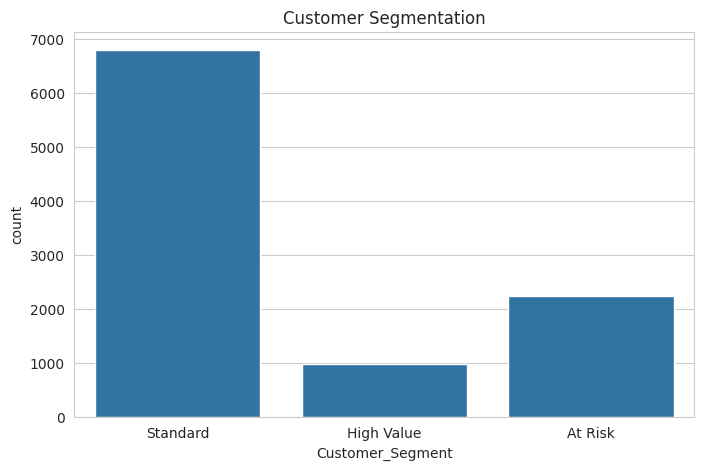

In [53]:
# Visualize Customer Segments

plt.figure(figsize=(8,5))

sns.countplot(x='Customer_Segment', data=rfm)

plt.title('Customer Segmentation')

plt.show()

In [54]:
# Merge Segmentation with Original Dataset

final_df = df.merge(
    rfm[['customer_id', 'Customer_Segment']],
    on='customer_id',
    how='left'
)

In [55]:
# View Final Dataset

final_df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,CLV,Customer_Segment
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.00,Standard
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,83807.86,Standard
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,478982.40,Standard
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.00,Standard
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,125510.82,Standard


In [56]:
# Export Final Dataset

final_df.to_csv(
    'Final_Banking_Churn_Analysis.csv',
    index=False
)

In [57]:
# Download Final Dataset

from google.colab import files

files.download('Final_Banking_Churn_Analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# Important Business Insights

print("Total Customers:", len(df))

print("Total Churn Customers:", df['churn'].sum())

print("Churn Rate:", round(churn_rate,2), "%")

print("Average Balance:", round(df['balance'].mean(),2))

print("Average Salary:", round(df['estimated_salary'].mean(),2))

Total Customers: 10000
Total Churn Customers: 2037
Churn Rate: 20.37 %
Average Balance: 76485.89
Average Salary: 100090.24


In [50]:
# High Value Customers Count

high_value = rfm[rfm['Customer_Segment'] == 'High Value']

print("High Value Customers:", len(high_value))

High Value Customers: 971


In [51]:
# At Risk Customers Count

at_risk = rfm[rfm['Customer_Segment'] == 'At Risk']

print("At Risk Customers:", len(at_risk))

At Risk Customers: 2237


**Key Findings**

Churn Customers
*   Customers with low activity show higher churn.
*   Older customers tend to churn more.
*   Customers with fewer products are more likely to leave.

High Value Customers
*   High balance and multiple products customers generate higher value.
*   Active members are more loyal.

Country Analysis
*   Churn varies across countries.
*   Some regions require stronger retention strategies.
